## Parameter estimation
Takes real S&P data and estimates mu and sigma using maximum lieklyhood estimation

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import yfinance as yf

collects data

In [13]:
ticker = "SPY"
data   = yf.download(ticker, start="2020-01-01", end="2024-01-01")
prices = data["Close"] # takes only closing price

print(f"Downloaded {len(prices)} days of {ticker} data")
print(f"From : {prices.index[0].date()}")
print(f"To   : {prices.index[-1].date()}")
print(f"Start price : ${prices.iloc[0].item():.2f}")
print(f"End price   : ${prices.iloc[-1].item():.2f}")

[*********************100%***********************]  1 of 1 completed

Downloaded 1006 days of SPY data
From : 2020-01-02
To   : 2023-12-29
Start price : $296.13
End price   : $461.39


calculates log return

In [14]:
log_returns = np.log(prices / prices.shift(1)).dropna() # log return of each trading day (close-to-close)

print(f"Number of log returns : {len(log_returns)}")
print(f"Mean daily log return : {log_returns.mean().item():.6f}")
print(f"Std  daily log return : {log_returns.std().item():.6f}")

Number of log returns : 1005
Mean daily log return : 0.000441
Std  daily log return : 0.014315


carries out MLE on daily data

In [15]:
mu_daily    = log_returns.mean().item() # daily log-return drift
sigma_daily = log_returns.std().item() # daily log-return volitility

anualises estimates using log-return distribution

In [16]:
sigma_hat = sigma_daily * np.sqrt(252) # measured variance is sigma^2 * delta_t (1/252). rearrange to get annual std estime
mu_hat    = mu_daily * 252 + 0.5 * sigma_hat**2  # measured mu is (mu- 1/2 *sigma^2) * delta_t. rearrange to get annual mu estimate

print(f"{'Parameter':20} {'Value':>10}")
print(f"{'annual drift':20} {mu_hat:>10.4f}")
print(f"{'annual volitility':20} {sigma_hat:>10.4f}")

Parameter                 Value
annual drift             0.1370
annual volitility        0.2272


## Simulation

In [17]:
from utils import gbm_simulate

Parameters

In [18]:
S0 = prices.iloc[0].item()
N = len(prices) - 1 # number of trading days
T = N/252 # time horizon (years)
I = 10

Run simulation

In [19]:
S, times = gbm_simulate(S0, mu_hat, sigma_hat, T, N, I)

print(f"Starting price   : ${S[0, 0]:.2f}")
print(f"Mean final price : ${S[-1].mean():.2f}")
print(f"Min  final price : ${S[-1].min():.2f}")
print(f"Max  final price : ${S[-1].max():.2f}")

Starting price   : $296.13
Mean final price : $615.08
Min  final price : $237.79
Max  final price : $1184.15


Plot simulations against SPY

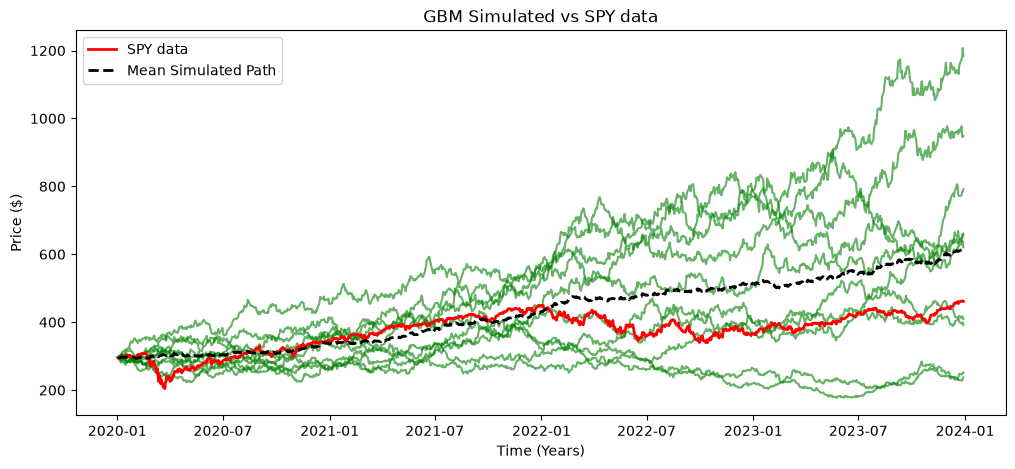

In [20]:
plt.figure(figsize=(12,5))

plt.plot(prices.index, S, alpha=0.6, color = "g") # simulated paths

plt.plot(prices.index, prices, lw=2, color = "r", label="SPY data") # real data

plt.plot(prices.index, S.mean(axis=1), lw=2, color='k', 
         linestyle='--', label='Mean Simulated Path') # average of simaltions


plt.title("GBM Simulated vs SPY data")
plt.xlabel("Time (Years)")
plt.ylabel("Price ($)")
plt.legend()
plt.show()

## Evaluation

Mean value of simulations follows real data well, suggesting our drift estimate is realtively accurate. However, the simulated paths have a evry large spread. This shows that our method of modelling volitility needs improvement. The cause of this is one of the main limitations of our GBM model, it assumes a constant  value for volitility over time. In realisty this is not the case.

One example of this is the 2020 market crash due to covid which can be seen near the beginning of our dataset. Volitlility spiked in this period and took time to return to normal levels. This is an example of volitility clustering.

## Rolling volitility
Plot volitlity over time to demonstrate volitility clustering

In [21]:
window_01 = 10 # 2 weeks
window_02 = 21 # one month


rolling_vol_01 = log_returns.rolling(window=window_01).std() * np.sqrt(252)
rolling_vol_02 = log_returns.rolling(window=window_02).std() * np.sqrt(252)


print(f"{'Window':12} {f'{window_01} days':>12} {f'{window_02} days':>12}")
print(f"{'Mean vol':12} {rolling_vol_01.mean().item():>12.4f} {rolling_vol_02.mean().item():>12.4f}")
print(f"{'Max vol':12} {rolling_vol_01.max().item():>12.4f} {rolling_vol_02.max().item():>12.4f}")
print(f"{'Min vol':12} {rolling_vol_01.min().item():>12.4f} {rolling_vol_02.min().item():>12.4f}")
print(f"Constant σ hat : {sigma_hat:.4f}")

Window            10 days      21 days
Mean vol           0.1856       0.1912
Max vol            1.1306       0.9367
Min vol            0.0455       0.0658
Constant σ hat : 0.2272


Plot rolling volitility

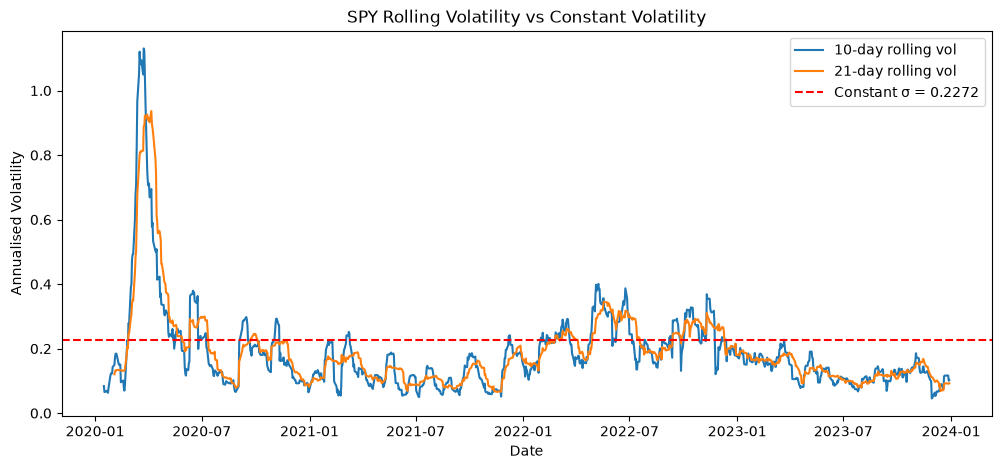

In [22]:
plt.figure(figsize=(12, 5))

plt.plot(rolling_vol_01.index, rolling_vol_01.values, 
        label=f'{window_01}-day rolling vol')
plt.plot(rolling_vol_02.index, rolling_vol_02.values, 
         label=f'{window_02}-day rolling vol')

plt.axhline(sigma_hat, color='red', linestyle='--', 
            lw=1.5, label=f'Constant σ = {sigma_hat:.4f}')

plt.title("SPY Rolling Volatility vs Constant Volatility")
plt.xlabel("Date")
plt.ylabel("Annualised Volatility")
plt.legend()
plt.show()

## Evaluation

We can see here that volitility is not constant as assumed in the GBM model. Notably, it is greatly elevated during the 2020 market crash.
We can clearly see volitility clustering. High volitility is followed by high volitility and low volitlity is followed by low volitlity.
The next stage woulld be to update our model to include this behaviour.